<a href="https://colab.research.google.com/github/ikoghoddds-bit/Data-Science-Portfolio-C21/blob/main/Projects/Project-6/Images-Description.for.Students_Pass_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Image Classification with Deep Learning



This project introduces us to deep learning. The deep learning process is a huge leap forward in data science and the field is less than 15 years old. The processing is significantly different from our previous projects so you will basically be provided a walkthrough document delineating the steps - much like Project 1. Deep learning is fascinating and I just want you to go through the process so you can appreciate its power.



The data collection portion of deep learning projects is a rather complex task. In other words, there is no CSV file that we can load to serve as our training data. Constructing a training data set is a rather large undertaking. We have imported all the training images (took hours) and I will show you how you can load the training data through the "pickle" process.



There are three files in this data set:
- [the feature set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle ), i.e. images of dogs and cats ( mostly )
- [the target set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle ), i.e. the label (0/1) that something is a dog or cat ( mostly )
- [a test image]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg )





This project will classify new, unseen images of cats and dogs. This was one of the first big success stories of deep learning and we will go through the process of building a learning algorithm that will do this task. Distinguishing a picture of a cat from a picture of a dog is easy for humans to do, but had been notoriously difficult to get a computer learning to perform well on the task. Deep learning solved that.


The same data sets as above, but you can copy the links by viewing the markdown directly to bypass Google Colab's annoying "You are leaving Colab" link.




https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg


In [ ]:
import pandas as pd


In [ ]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [ ]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [ ]:
image_array.shape

(24946, 100, 100, 1)

In [ ]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [ ]:
target = pd.read_pickle( target_url )
type(target)


list

In [ ]:
image_url = ''

## Library Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
import urllib.request
import cv2

## Verify GPU Enabled

In [ ]:
# Verify GPU is enabled and detected by TensorFlow

print("GPU Devices Available: ", tf.config.list_physical_devices('GPU'))

GPU Devices Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Collection

### Load Pickled Data

In [ ]:
# Load the Pickled Data

X_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
y_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"

X_full = pd.read_pickle(X_url)
y_full = np.array(pd.read_pickle(y_url))

# Subsample for Pass 5 (10,000 images, randomized)

np.random.seed(42)
indices = np.arange(len(X_full))
np.random.shuffle(indices)

# INCREASE TO 10000

subset_indices = indices[:10000]
X_subset = X_full[subset_indices]
y_subset = y_full[subset_indices]

# Data Cleaning (Scaling)

X_subset = X_subset / 255.0

### Exploratory Data Analysis (EDA)

In [ ]:
# Verify Dimensionality

print(f"X_subset shape: {X_subset.shape}") # Should be (10000, 100, 100, 1)
print(f"y_subset shape: {y_subset.shape}") # Should be (10000,)

X_subset shape: (10000, 100, 100, 1)
y_subset shape: (10000,)


### Visual Inspection and Label Verification

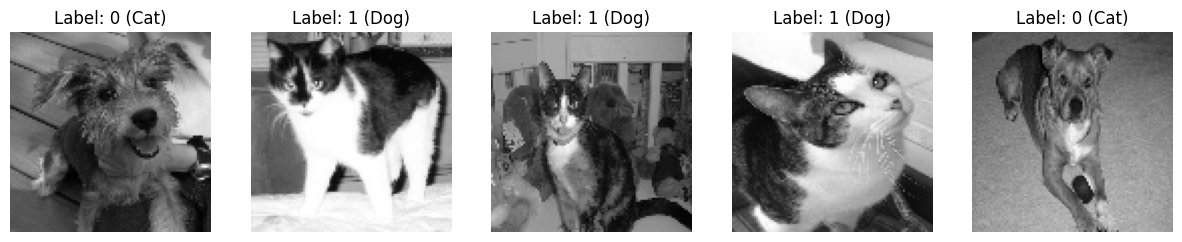

In [ ]:
# Visual Inspection and Label Verification

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_subset[i].reshape(100, 100), cmap='gray')
    label = "Dog" if y_subset[i] == 1 else "Cat"
    plt.title(f"Label: {y_subset[i]} ({label})")
    plt.axis('off')
plt.show()

## CNN Architecture & Compilation

### Train_Test Split

In [ ]:
# Train-Test Split (80/20 split)

# This results in 8,000 training images and 2,000 testing images

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.20, random_state=42
)

# Build the Sequential Model

model = Sequential()

# Add Convolutional Blocks

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(100, 100, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Define the Output Layer

model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# Compile the Engine

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        33,857 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,673 (205.75 KB)

 Trainable params: 52,673 (205.75 KB)

 Non-trainable params: 0 (0.00 B)

## Training and Prediction

### Fitting The Model

In [ ]:
# Fit the Model

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

# Evaluate Performance

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# External Prediction Function

def predict_external_image(image_url, current_model):
    req = urllib.request.urlopen(image_url)
    arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)

    img_resized = cv2.resize(img, (100, 100))
    img_scaled = img_resized / 255.0
    img_reshaped = img_scaled.reshape(1, 100, 100, 1)

    prediction = current_model.predict(img_reshaped)[0][0]
    predicted_class = "Dog" if prediction > 0.5 else "Cat"

    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Prediction: {predicted_class} (Prob: {prediction:.4f})")
    plt.axis('off')
    plt.show()

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9289 - loss: 0.1924 - val_accuracy: 0.7590 - val_loss: 0.5942
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9465 - loss: 0.1602 - val_accuracy: 0.7695 - val_loss: 0.5955
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9594 - loss: 0.1294 - val_accuracy: 0.7550 - val_loss: 0.6808
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9711 - loss: 0.1015 - val_accuracy: 0.7695 - val_loss: 0.7179
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9775 - loss: 0.0842 - val_accuracy: 0.7695 - val_loss: 0.7506
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9871 - loss: 0.0610 - val_accuracy: 0.7650 - val_loss: 0.7872
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9911 - loss: 0.0486 - val_accuracy: 0.7585 - val_loss: 0.9087
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9937 - loss: 0.0386 - val_accu

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


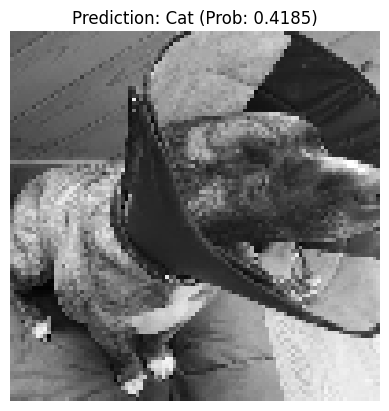

In [ ]:
# Test the function with the provided dog image

dog_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"
predict_external_image(dog_url, model)

## Pass 2 Analytical Review

In [ ]:
# Generate predictions for the test set

test_predictions = model.predict(X_test).flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


NOTE FOR ANALYSIS:
The distribution now features two massive spikes at the extreme ends (near 0.0 and 1.0), indicating the model is highly confident in the majority of its classifications.

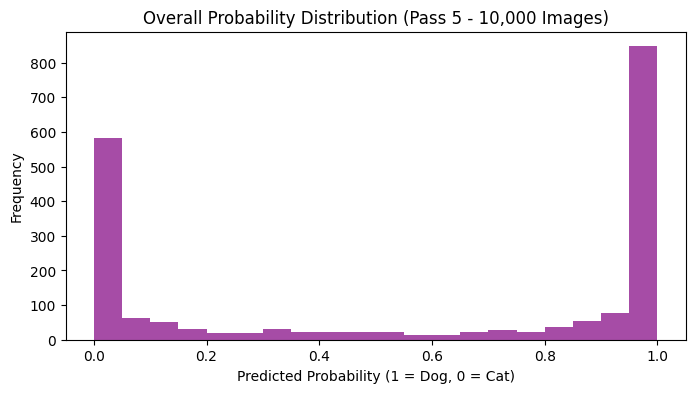

In [ ]:
# Overall Probability Distributions

plt.figure(figsize=(8, 4))
plt.hist(test_predictions, bins=20, color='purple', alpha=0.7)
plt.title("Overall Probability Distribution (Pass 5 - 10,000 Images)")
plt.xlabel("Predicted Probability (1 = Dog, 0 = Cat)")
plt.ylabel("Frequency")
plt.show()

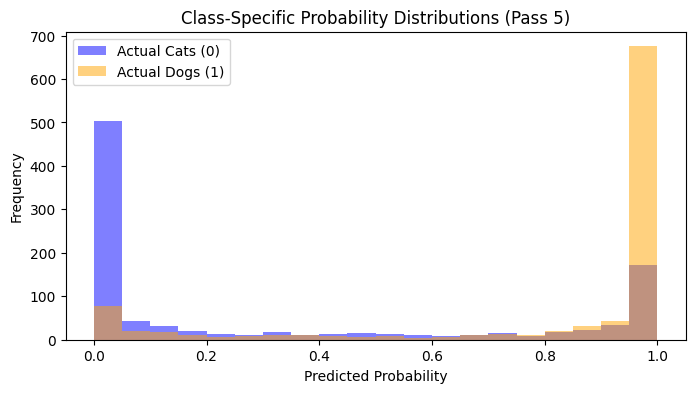

In [ ]:
# Class-Specific Probability Distributions

plt.figure(figsize=(8, 4))
plt.hist(test_predictions[y_test == 0], bins=20, color='blue', alpha=0.5, label='Actual Cats (0)')
plt.hist(test_predictions[y_test == 1], bins=20, color='orange', alpha=0.5, label='Actual Dogs (1)')
plt.title("Class-Specific Probability Distributions (Pass 5)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
# High-Confidence False Positives (Actually Dog, Predicted Cat)

false_cats = np.where((y_test == 1) & (test_predictions < 0.1))[0]

# High-Confidence False Negatives (Actually Cat, Predicted Dog)

false_dogs = np.where((y_test == 0) & (test_predictions > 0.9))[0]

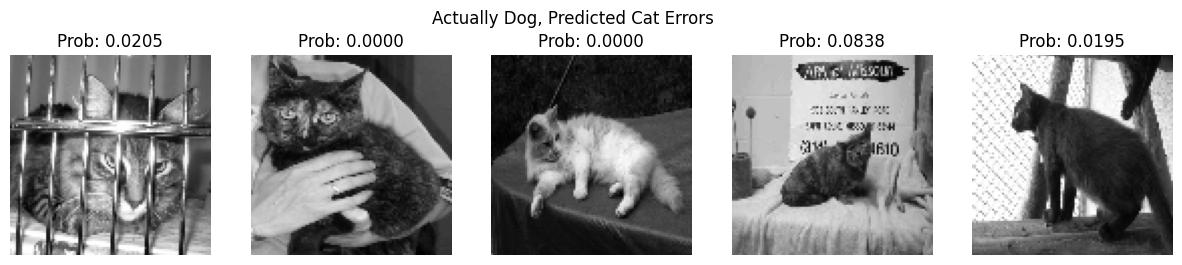

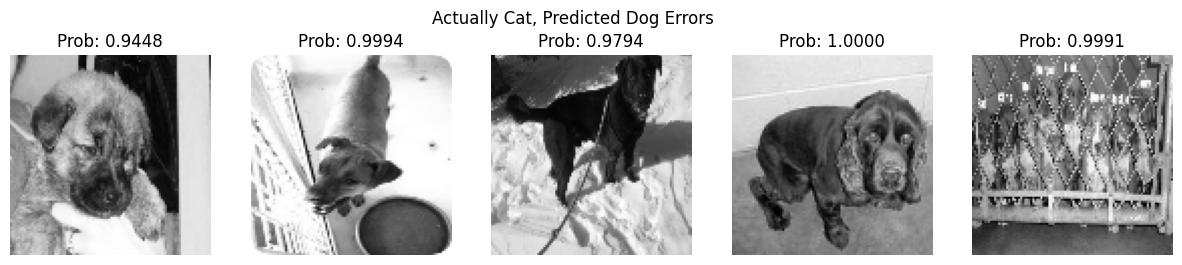

In [ ]:
# Visually Inspecting Oddities

def plot_errors(error_indices, title_prefix):
    if len(error_indices) == 0:
        print(f"No {title_prefix} found at this confidence threshold.")
        return

    plt.figure(figsize=(15, 3))

    # Plot up to 5 errors

    plot_count = min(len(error_indices), 5)
    for i in range(plot_count):
        idx = error_indices[i]
        plt.subplot(1, 5, i+1)
        plt.imshow(X_test[idx].reshape(100, 100), cmap='gray')
        plt.title(f"Prob: {test_predictions[idx]:.4f}")
        plt.axis('off')
    plt.suptitle(f"{title_prefix} Errors")
    plt.show()

plot_errors(false_cats, "Actually Dog, Predicted Cat")
plot_errors(false_dogs, "Actually Cat, Predicted Dog")

## Hyperparameter Experimentation

In [ ]:
from tensorflow.keras.layers import Dropout

In [ ]:
# Experimental Model: Deepening the network to three convolutional blocks

exp_model_5 = Sequential()

# Block 1

exp_model_5.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(100, 100, 1)))
exp_model_5.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2

exp_model_5.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
exp_model_5.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3 (New)

exp_model_5.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
exp_model_5.add(MaxPooling2D(pool_size=(2, 2)))

# Output Layer

exp_model_5.add(Flatten())
exp_model_5.add(Dense(64, activation='relu')) # Added dense layer for better processing
exp_model_5.add(Dropout(0.5))
exp_model_5.add(Dense(1, activation='sigmoid'))

exp_model_5.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the experimental model

exp_history_5 = exp_model_5.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5098 - loss: 0.6918 - val_accuracy: 0.5685 - val_loss: 0.6834
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5658 - loss: 0.6822 - val_accuracy: 0.6255 - val_loss: 0.6684
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6299 - loss: 0.6487 - val_accuracy: 0.6665 - val_loss: 0.6156
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6731 - loss: 0.6062 - val_accuracy: 0.7185 - val_loss: 0.5550
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7276 - loss: 0.5463 - val_accuracy: 0.7650 - val_loss: 0.4952
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7566 - loss: 0.5107 - val_accuracy: 0.7645 - val_loss: 0.4941
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7819 - loss: 0.4717 - val_accuracy: 0.7750 - val_loss: 0.4663
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7936 - loss: 0.4419 - val_accu